# Reducing User Churn & Increasing Premium Adoption: A Spotify Product Analytics Case Study

**Product area:** Free-to-Premium conversion, engagement, and retention
**Dataset:** [Spotify User Behavior and Pattern](https://www.kaggle.com/datasets/sahilislam007/spotify-user-behavior-and-pattern) (Kaggle, 50,000 simulated users)

## Executive Summary

Spotify monetizes primarily through Premium subscriptions and ad-supported free listening. This case study analyzes user behavior data to answer three questions a Growth PM needs answered before writing a roadmap:

1. **Who converts to Premium, and who doesn't?** (funnel and segmentation analysis)
2. **Which free users are the best upsell targets?** (high-value free user identification)
3. **Which users are at risk of disengaging, and what predicts it?** (churn/inactivity modeling)

The output of this notebook feeds directly into the accompanying **Product Requirements Document (PRD)**, which proposes a phased initiative to lift Premium conversion and reduce churn. Wherever this notebook produces a metric referenced in the PRD, it is called out explicitly so the two documents stay in sync — re-run this notebook and update the PRD's metrics table before each planning cycle.

> **Note on the model as a proxy:** the dataset does not contain a true subscription-cancellation event, so `inactive_3_months_flag` (3+ months without listening activity) is used throughout as a proxy for disengagement/churn risk. This is called out again in the Churn Modeling section and in the PRD's Assumptions & Risks.


## 1. Business Problem

Free-to-paid conversion and retention are the two levers that most directly drive subscription revenue. Two problems motivate this analysis:

- **Under-monetized engaged free users.** Some free users interact heavily with the product (including ads) but never convert — these represent unrealized revenue if we can identify what's blocking them.
- **Silent disengagement.** Users who go quiet for 3+ months are unlikely to convert or renew, and today there's no systematic way to flag them before they're gone.

## 2. Objective

Use the available behavioral data to:
- Quantify the current Free vs. Premium mix and conversion funnel.
- Identify **high-value free users** — an actionable target segment for upsell.
- Segment the broader user base into behaviorally distinct groups.
- Build a first-pass **churn/inactivity risk model** to flag at-risk users.
- Translate these findings into product recommendations (see final section and the PRD).

## 3. Key Questions / Hypotheses

| # | Question | Hypothesis |
|---|---|---|
| H1 | Does ad interaction correlate with Premium conversion? | Users who interact with ads convert at a meaningfully different rate than those who don't, suggesting ads are a conversion touchpoint worth optimizing. |
| H2 | Are there free users who look like good upsell candidates? | A meaningful subset of free users interact with ads (engaged) but haven't converted — these are higher-intent than the average free user. |
| H3 | Does geography affect conversion? | Premium adoption rates vary meaningfully by country, implying pricing/marketing should not be one-size-fits-all. |
| H4 | Can we predict inactivity (churn proxy) from basic usage signals? | Age, inactivity history, ad behavior, and subscription type together carry predictive signal for 3+ month inactivity. |
| H5 | Do natural user segments exist? | Clustering on behavioral features reveals distinct groups (e.g., engaged premium, at-risk free, dormant, etc.) that warrant different product treatment. |

## 4. Methodology

1. Load and clean the raw behavioral dataset (50K simulated users).
2. Exploratory analysis of the Free/Premium split, demographics, and geography.
3. Ad interaction and conversion funnel analysis.
4. Identification of the high-value free user segment.
5. Unsupervised segmentation (K-Means) across behavioral features.
6. Supervised churn-risk model (logistic regression) using inactivity as the target.
7. Summary KPI dashboard + product recommendations.


## 5. Setup

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
)

# display settings
pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")


### 5.1 Load data

In [2]:
import kagglehub

path = kagglehub.dataset_download("sahilislam007/spotify-user-behavior-and-pattern")
print("Path to dataset files:", path)


100%|██████████| 1.00M/1.00M [00:00<00:00, 47.9MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/sahilislam007/spotify-user-behavior-and-pattern/versions/1


In [3]:
import os

print(os.listdir(path))


['spotify_user_behavior_realistic_50000_rows.csv']


## 6. Exploratory Data Analysis

**Product question this section answers:** *What does our user base actually look like, and what's the baseline Free/Premium mix?* This grounds every downstream recommendation in the actual scale of the opportunity.


In [4]:
df = pd.read_csv(os.path.join(path, "spotify_user_behavior_realistic_50000_rows.csv"))

df.head()


,user_id,country,age,signup_date,subscription_type,subscription_status,months_inactive,inactive_3_months_flag,ad_interaction,ad_conversion_to_subscription,music_suggestion_rating_1_to_5,avg_listening_hours_per_week,favorite_genre,most_liked_feature,desired_future_feature,primary_device,playlists_created,avg_skips_per_day
0,1,France,25,2021-08-19,Premium Duo,Active,0,0,No,No,4,10.13,Bollywood,Radio,Concert Alerts,Tablet,7,8
1,2,Indonesia,20,2022-06-06,Premium Family,Active,0,0,Yes,No,5,11.63,Latin,Podcasts,Lyrics Translation,Mobile,7,6
2,3,Italy,53,2024-01-04,Premium Individual,Active,0,0,Yes,Yes,3,9.50,Bollywood,Lyrics,Better AI Recommendations,Desktop,6,5
3,4,Italy,48,2018-08-26,Premium Individual,Active,1,0,No,No,4,13.16,Electronic,Playlists,Social Listening,Smart Speaker,11,8
4,5,Australia,18,2020-05-29,Free,Active,0,0,No,No,4,12.70,Indie,Daily Mix,Lyrics Translation,Tablet,10,11


In [5]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.info()


Rows: 50000
Columns: 18
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 18 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   user_id                         50000 non-null  int64  
 1   country                         50000 non-null  object 
 2   age                             50000 non-null  int64  
 3   signup_date                     50000 non-null  object 
 4   subscription_type               50000 non-null  object 
 5   subscription_status             50000 non-null  object 
 6   months_inactive                 50000 non-null  int64  
 7   inactive_3_months_flag          50000 non-null  int64  
 8   ad_interaction                  50000 non-null  object 
 9   ad_conversion_to_subscription   50000 non-null  object 
 10  music_suggestion_rating_1_to_5  50000 non-null  int64  
 11  avg_listening_hours_per_week    50000 non-null  float64
 12  favorite

In [6]:
missing = df.isnull().sum()

missing[missing > 0].sort_values(ascending=False)


,0


In [7]:
df.describe(include='all')


,user_id,country,age,signup_date,subscription_type,subscription_status,months_inactive,inactive_3_months_flag,ad_interaction,ad_conversion_to_subscription,music_suggestion_rating_1_to_5,avg_listening_hours_per_week,favorite_genre,most_liked_feature,desired_future_feature,primary_device,playlists_created,avg_skips_per_day
count,50000.000000,50000,50000.000000,50000,50000,50000,50000.000000,50000.000000,50000,50000,50000.000000,50000.000000,50000,50000,50000,50000,50000.000000,50000.000000
unique,NaN,12,NaN,2982,5,2,NaN,NaN,2,2,NaN,NaN,12,8,6,5,NaN,NaN
top,NaN,India,NaN,2026-01-18,Free,Active,NaN,NaN,No,No,NaN,NaN,Classical,Lyrics,Mood-based Auto Playlists,Smart Speaker,NaN,NaN
freq,NaN,4265,NaN,33,22525,42109,NaN,NaN,32514,45648,NaN,NaN,4272,6358,8419,10050,NaN,NaN
mean,25000.500000,NaN,38.010280,NaN,NaN,NaN,1.533020,0.222460,NaN,NaN,3.644100,9.988986,NaN,NaN,NaN,NaN,8.002680,10.025920
std,14433.901067,NaN,12.984989,NaN,NaN,NaN,1.952082,0.415903,NaN,NaN,1.114424,3.968927,NaN,NaN,NaN,NaN,2.831571,3.165579
min,1.000000,NaN,16.000000,NaN,NaN,NaN,0.000000,0.000000,NaN,NaN,1.000000,0.000000,NaN,NaN,NaN,NaN,0.000000,1.000000
25%,12500.750000,NaN,27.000000,NaN,NaN,NaN,0.000000,0.000000,NaN,NaN,3.000000,7.280000,NaN,NaN,NaN,NaN,6.000000,8.000000
50%,25000.500000,NaN,38.000000,NaN,NaN,NaN,1.000000,0.000000,NaN,NaN,4.000000,9.980000,NaN,NaN,NaN,NaN,8.000000,10.000000
75%,37500.250000,NaN,49.000000,NaN,NaN,NaN,2.000000,0.000000,NaN,NaN,5.000000,12.680000,NaN,NaN,NaN,NaN,10.000000,12.000000


In [8]:
df.columns.tolist()


['user_id',
 'country',
 'age',
 'signup_date',
 'subscription_type',
 'subscription_status',
 'months_inactive',
 'inactive_3_months_flag',
 'ad_interaction',
 'ad_conversion_to_subscription',
 'music_suggestion_rating_1_to_5',
 'avg_listening_hours_per_week',
 'favorite_genre',
 'most_liked_feature',
 'desired_future_feature',
 'primary_device',
 'playlists_created',
 'avg_skips_per_day']

### 6.1 Free vs. Premium mix

In [9]:
# Derive a clean binary premium flag and a readable label from subscription_type.
df['premium_user'] = df['subscription_type'].str.contains('premium', case=False, na=False).astype(int)
df['user_type'] = np.where(df['premium_user'] == 1, 'Premium User', 'Free User')

df[['subscription_type', 'premium_user', 'user_type']].head()


,subscription_type,premium_user,user_type
0,Premium Duo,1,Premium User
1,Premium Family,1,Premium User
2,Premium Individual,1,Premium User
3,Premium Individual,1,Premium User
4,Free,0,Free User


In [10]:
total_users = len(df)
premium_rate = df['premium_user'].mean() * 100
free_rate = 100 - premium_rate

print(f"Total Users: {total_users}")
print(f"Premium Subscription Rate: {premium_rate:.2f}%")
print(f"Free User Rate: {free_rate:.2f}%")


Total Users: 50000
Premium Subscription Rate: 45.92%
Free User Rate: 54.08%


In [11]:
# subscription breakdown
df['subscription_type'].value_counts()


,count
subscription_type,
Free,22525
Premium Individual,14029
Student,4516
Premium Family,4482
Premium Duo,4448


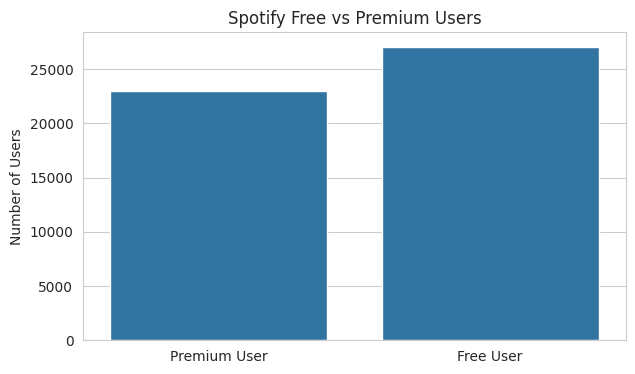

In [12]:
plt.figure(figsize=(7,4))
sns.countplot(data=df, x='user_type')
plt.title("Spotify Free vs Premium Users")
plt.xlabel("")
plt.ylabel("Number of Users")
plt.show()


> **Product insight:** the Premium rate above is the baseline conversion metric the PRD's success metrics are measured against — see *PRD Section 4: Goals & Success Metrics*.


### 6.2 Demographics

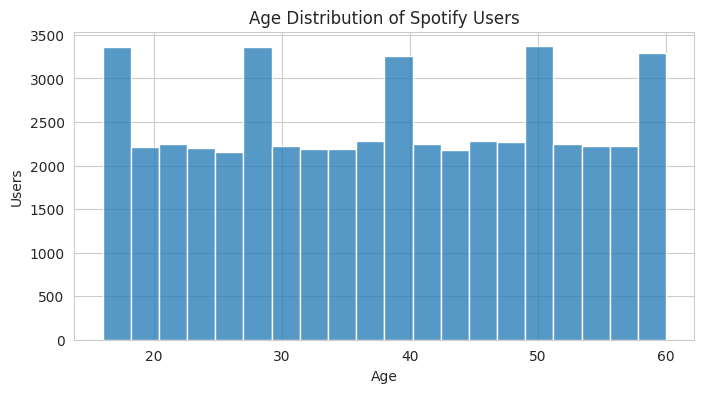

In [13]:
plt.figure(figsize=(8,4))
sns.histplot(data=df, x='age', bins=20)
plt.title("Age Distribution of Spotify Users")
plt.xlabel("Age")
plt.ylabel("Users")
plt.show()


### 6.3 Geography — does conversion vary by market? (H3)

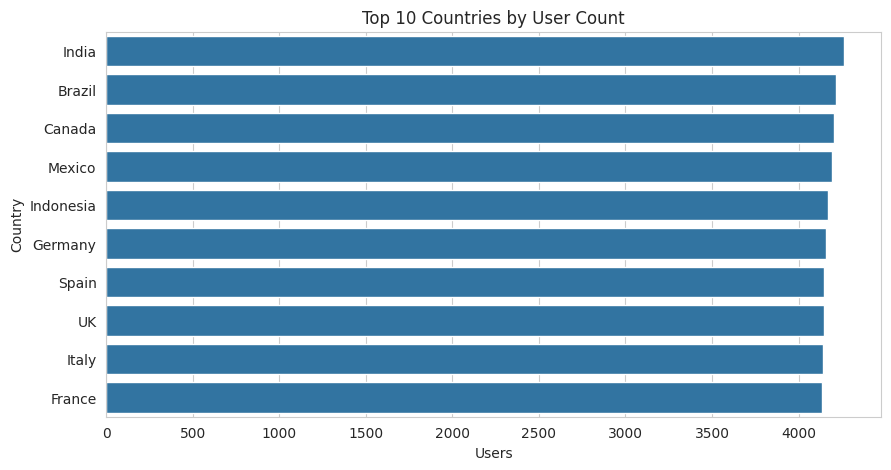

In [14]:
plt.figure(figsize=(10,5))
top_countries = df['country'].value_counts().head(10)

sns.barplot(x=top_countries.values, y=top_countries.index)
plt.title("Top 10 Countries by User Count")
plt.xlabel("Users")
plt.ylabel("Country")
plt.show()


In [15]:
# premium rate by country
country_premium = (
    df.groupby('country')['premium_user']
    .mean()
    .sort_values(ascending=False)
    .head(10) * 100
)

country_premium


,premium_user
country,
USA,47.268293
Germany,47.115385
India,47.057444
Spain,46.951073
Canada,46.181299
Mexico,46.163012
Indonesia,45.613615
Brazil,45.338078
UK,45.285749


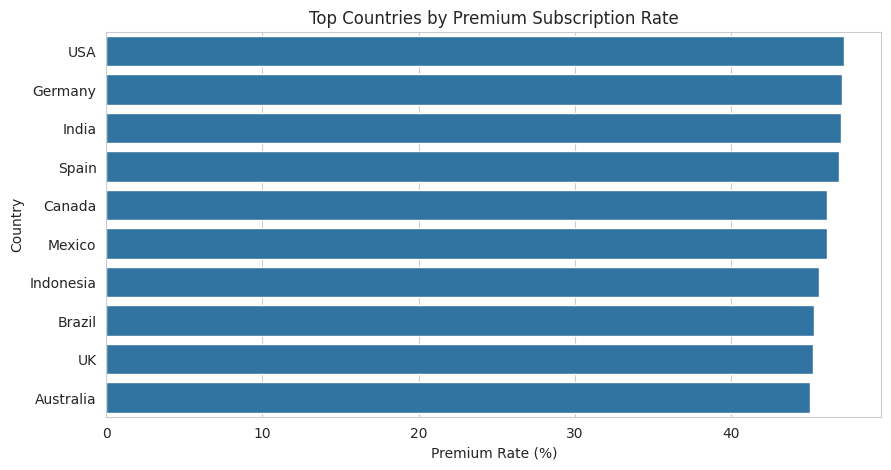

In [16]:
plt.figure(figsize=(10,5))
sns.barplot(x=country_premium.values, y=country_premium.index)
plt.title("Top Countries by Premium Subscription Rate")
plt.xlabel("Premium Rate (%)")
plt.ylabel("Country")
plt.show()


> **Product insight:** if Premium rate is meaningfully uneven across the top markets shown above, that supports **H3** and argues for market-specific pricing/marketing experiments rather than a single global lever. Flag the top and bottom markets here for the PRD's rollout sequencing (*PRD Section 9: Phased Rollout*).


### 6.4 Inactivity by user type (H4 groundwork)

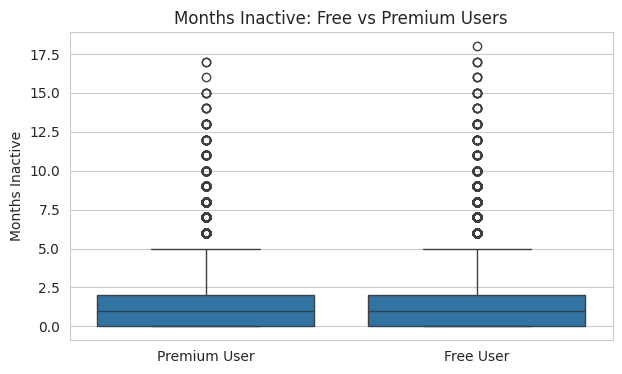

,inactive_3_months_flag
user_type,
Free User,22.036907
Premium User,22.492269


In [17]:
plt.figure(figsize=(7,4))
sns.boxplot(data=df, x='user_type', y='months_inactive')
plt.title("Months Inactive: Free vs Premium Users")
plt.xlabel("")
plt.ylabel("Months Inactive")
plt.show()

inactive_rate = df.groupby('user_type')['inactive_3_months_flag'].mean() * 100
inactive_rate


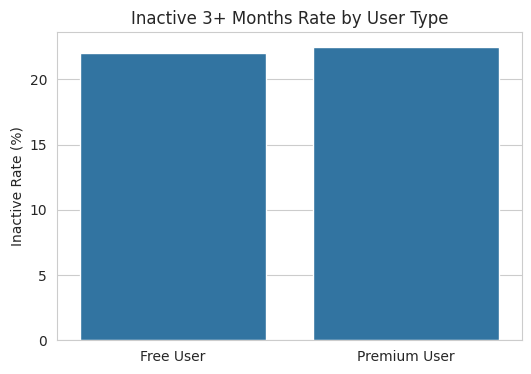

In [18]:
plt.figure(figsize=(6,4))
sns.barplot(x=inactive_rate.index, y=inactive_rate.values)
plt.title("Inactive 3+ Months Rate by User Type")
plt.xlabel("")
plt.ylabel("Inactive Rate (%)")
plt.show()


## 7. Ad Interactions & the Monetization Funnel

**Product question this section answers:** *Is ad interaction a meaningful signal for conversion (H1), and where does the funnel leak?* This section directly informs the PRD's **Ad Experience & Conversion Optimization** epic.


In [19]:
print(df['ad_interaction'].value_counts(dropna=False))
print(df['ad_conversion_to_subscription'].value_counts(dropna=False))


ad_interaction
No     32514
Yes    17486
Name: count, dtype: int64
ad_conversion_to_subscription
No     45648
Yes     4352
Name: count, dtype: int64


In [20]:
# Encode Yes/No columns as binary flags for analysis.
df['ad_interaction'] = df['ad_interaction'].map({'Yes': 1, 'No': 0})
df['ad_conversion_to_subscription'] = df['ad_conversion_to_subscription'].map({'Yes': 1, 'No': 0})

print(df['ad_interaction'].value_counts(dropna=False))
print(df['ad_conversion_to_subscription'].value_counts(dropna=False))


ad_interaction
0    32514
1    17486
Name: count, dtype: int64
ad_conversion_to_subscription
0    45648
1     4352
Name: count, dtype: int64


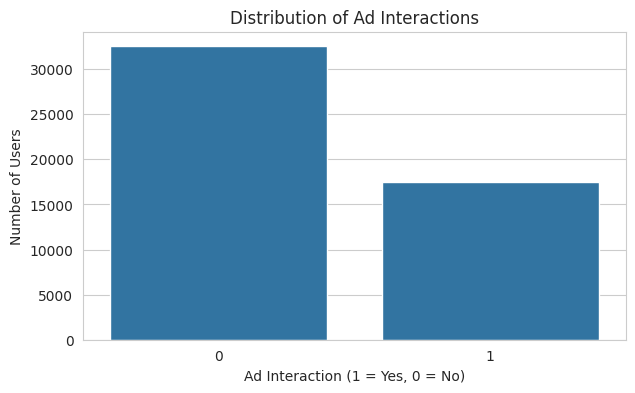

In [21]:
plt.figure(figsize=(7,4))
sns.countplot(data=df, x='ad_interaction', order=df['ad_interaction'].value_counts().index)
plt.title("Distribution of Ad Interactions")
plt.xlabel("Ad Interaction (1 = Yes, 0 = No)")
plt.ylabel("Number of Users")
plt.show()


### 7.1 Conversion rate by ad interaction (H1)

In [22]:
ad_conversion_summary = (
    df.groupby('ad_interaction')['ad_conversion_to_subscription']
      .agg(['count', 'sum', 'mean'])
      .reset_index()
)

ad_conversion_summary.columns = [
    'Ad Interaction',
    'Total Users',
    'Paid Conversions',
    'Conversion Rate',
]

ad_conversion_summary['Conversion Rate'] *= 100
ad_conversion_summary.sort_values(by='Conversion Rate', ascending=False, inplace=True)

ad_conversion_summary


,Ad Interaction,Total Users,Paid Conversions,Conversion Rate
1,1,17486,4352,24.888482
0,0,32514,0,0.000000


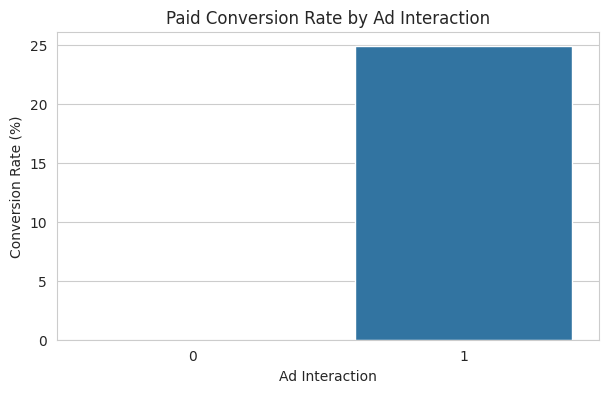

In [23]:
plt.figure(figsize=(7,4))
sns.barplot(data=ad_conversion_summary, x='Ad Interaction', y='Conversion Rate')
plt.title("Paid Conversion Rate by Ad Interaction")
plt.xlabel("Ad Interaction")
plt.ylabel("Conversion Rate (%)")
plt.show()


### 7.2 Conversion funnel

In [24]:
total_users = len(df)
free_users_n = len(df[df['premium_user'] == 0])
ad_interactors = len(df[df['ad_interaction'] == 1])
ad_converted = len(df[df['ad_conversion_to_subscription'] == 1])
premium_users_n = len(df[df['premium_user'] == 1])

funnel = pd.DataFrame({
    'Stage': [
        'Total Users',
        'Free Users',
        'Ad Interactors',
        'Ad Converted to Paid',
        'Premium Users',
    ],
    'Users': [
        total_users,
        free_users_n,
        ad_interactors,
        ad_converted,
        premium_users_n,
    ],
})

funnel


,Stage,Users
0,Total Users,50000
1,Free Users,27041
2,Ad Interactors,17486
3,Ad Converted to Paid,4352
4,Premium Users,22959


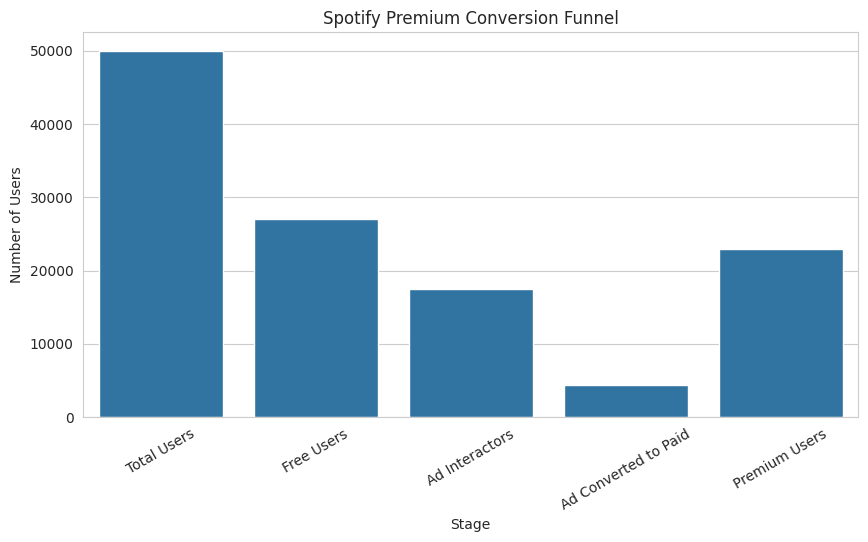

In [25]:
plt.figure(figsize=(10,5))
sns.barplot(data=funnel, x='Stage', y='Users')
plt.title("Spotify Premium Conversion Funnel")
plt.xticks(rotation=30)
plt.ylabel("Number of Users")
plt.show()


### 7.3 High-value free users (H2)

**Definition:** free users who *interact* with ads (i.e., they're engaged enough to notice/act on ads) but have *not* converted to Premium. This is the highest-intent, lowest-effort segment to target with an upsell push, and is the core target segment for the PRD's **High-Value Free User Upsell** epic.


In [26]:
high_value_free_users = df[
    (df['premium_user'] == 0) &
    (df['ad_interaction'] == 1) &
    (df['ad_conversion_to_subscription'] == 0)
]

print("High-value free users:", len(high_value_free_users))
print("Percent of dataset:", len(high_value_free_users) / len(df) * 100)

high_value_free_users.head()


High-value free users: 7077
Percent of dataset: 14.154


,user_id,country,age,signup_date,subscription_type,subscription_status,months_inactive,inactive_3_months_flag,ad_interaction,ad_conversion_to_subscription,music_suggestion_rating_1_to_5,avg_listening_hours_per_week,favorite_genre,most_liked_feature,desired_future_feature,primary_device,playlists_created,avg_skips_per_day,premium_user,user_type
25,26,UK,31,2023-01-31,Free,Active,1,0,1,0,4,4.48,Bollywood,Playlists,Better AI Recommendations,Car System,9,10,0,Free User
29,30,Spain,34,2021-11-07,Free,Active,0,0,1,0,5,8.27,Bollywood,Podcasts,Concert Alerts,Smart Speaker,8,8,0,Free User
38,39,France,47,2025-10-18,Free,Active,1,0,1,0,3,8.95,Country,Discover Weekly,Mood-based Auto Playlists,Smart Speaker,4,12,0,Free User
41,42,USA,58,2021-01-10,Free,Active,2,0,1,0,5,14.33,R&B,Daily Mix,Mood-based Auto Playlists,Smart Speaker,8,10,0,Free User
43,44,Canada,52,2025-11-13,Free,Active,0,0,1,0,5,9.82,Latin,Playlists,Lyrics Translation,Car System,12,9,0,Free User


In [27]:
# average profile of high-value free users
high_value_free_users.mean(numeric_only=True)


,0
user_id,25111.073901
age,37.868730
months_inactive,1.551505
inactive_3_months_flag,0.222976
ad_interaction,1.000000
ad_conversion_to_subscription,0.000000
music_suggestion_rating_1_to_5,3.649852
avg_listening_hours_per_week,10.072508
playlists_created,7.954924
avg_skips_per_day,10.005511


## 8. User Segmentation (H5)

**Product question this section answers:** *Do natural behavioral segments exist that should be treated differently in product/marketing?* Feeds the PRD's **Segment-Based Personalization** epic and persona definitions.


In [28]:
segment_features = [
    'age',
    'months_inactive',
    'inactive_3_months_flag',
    'ad_interaction',
    'ad_conversion_to_subscription',
    'premium_user',
]

X_segment = df[segment_features].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_segment)

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['user_segment'] = kmeans.fit_predict(X_scaled)

df[['user_id', 'user_type', 'user_segment']].head()


,user_id,user_type,user_segment
0,1,Premium User,0
1,2,Premium User,0
2,3,Premium User,3
3,4,Premium User,0
4,5,Free User,1


In [29]:
# segment size
df['user_segment'].value_counts().sort_index()


,count
user_segment,
0,16216
1,19284
2,10155
3,4345


In [30]:
# segment profile — the average behavior of each cluster, used to name/interpret segments
segment_profile = df.groupby('user_segment')[segment_features].mean()

segment_profile


,age,months_inactive,inactive_3_months_flag,ad_interaction,ad_conversion_to_subscription,premium_user
user_segment,,,,,,
0,38.018562,0.685311,0.000000,0.289714,0.000000,1.000000
1,37.962715,0.677557,0.000000,0.285159,0.000000,0.000000
2,38.025505,4.520532,1.000000,0.289906,0.000689,0.460955
3,38.154891,1.511162,0.222785,1.000000,1.000000,0.474568


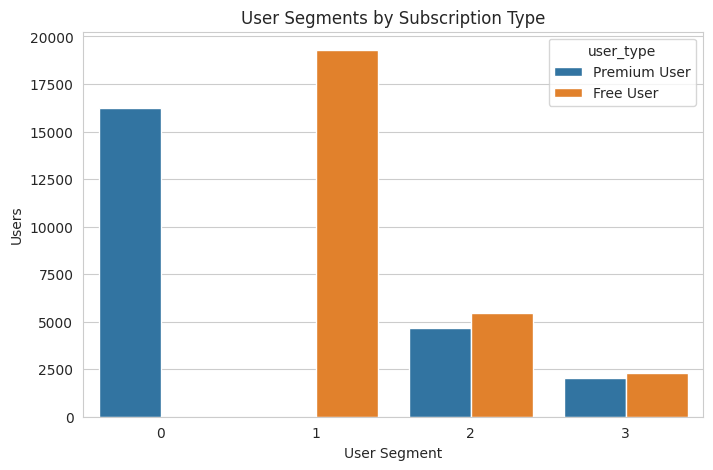

In [31]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='user_segment', hue='user_type')
plt.title("User Segments by Subscription Type")
plt.xlabel("User Segment")
plt.ylabel("Users")
plt.show()


> **Product insight:** name each cluster based on `segment_profile` above (e.g., "Engaged Premium," "Ad-Responsive Free," "Dormant/At-Risk," "New/Low-Signal") and carry these names into the PRD's persona section — clusters without a clear product action attached to them aren't actionable, so define the intended treatment for each segment before finalizing names.


## 9. Churn / Inactivity Risk Model (H4)

**Product question this section answers:** *Can we flag at-risk users before they go dark, using signals we already have?* This model is the foundation for the PRD's **Churn Early-Warning & Retention** epic.

**Caveat (repeated from the executive summary):** the dataset has no explicit cancellation/churn event, so this model predicts `inactive_3_months_flag` — 3+ consecutive months of inactivity — as a proxy for disengagement. Treat this as a first-pass risk signal, not a validated churn model, until it can be checked against real subscription-cancellation data.


In [32]:
features = [
    'age',
    'months_inactive',
    'ad_interaction',
    'ad_conversion_to_subscription',
    'premium_user',
]

X = df[features]
y = df['inactive_3_months_flag']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y,
)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      7775
           1       1.00      1.00      1.00      2225

    accuracy                           1.00     10000
   macro avg       1.00      1.00      1.00     10000
weighted avg       1.00      1.00      1.00     10000



In [33]:
# feature importance for logistic regression
coef_df = pd.DataFrame({
    'Feature': features,
    'Coefficient': model.coef_[0],
}).sort_values(by='Coefficient', ascending=False)

coef_df


,Feature,Coefficient
1,months_inactive,11.871399
3,ad_conversion_to_subscription,0.556371
4,premium_user,0.088847
0,age,-0.000492
2,ad_interaction,-0.347273


> **Product insight:** whichever features carry the largest positive coefficients above are the leading indicators to surface in a retention dashboard or trigger for a win-back campaign. Whichever carry the largest negative coefficients describe your "safe"/sticky users — useful for defining who *not* to spend retention budget on. Carry the ranked feature list into the PRD's **Functional Requirements** for the risk-scoring service.


## 10. Product Summary Dashboard

This is the canonical set of top-line metrics referenced by the PRD's success metrics table. **Re-run this cell and update the PRD whenever the underlying data changes.**


In [34]:
print(f"Total Users: {len(df)}")
print(f"Premium Subscription Rate: {df['premium_user'].mean() * 100:.2f}%")
print(f"Free User Rate: {(1 - df['premium_user'].mean()) * 100:.2f}%")
print(f"Ad Interaction Rate: {df['ad_interaction'].mean() * 100:.2f}%")
print(f"Ad Conversion to Paid Rate: {df['ad_conversion_to_subscription'].mean() * 100:.2f}%")
print(f"Inactive 3+ Months Rate: {df['inactive_3_months_flag'].mean() * 100:.2f}%")
print(f"High-Value Free Users: {len(high_value_free_users)}")
print(f"High-Value Free Users (% of all users): {len(high_value_free_users) / len(df) * 100:.2f}%")


Total Users: 50000
Premium Subscription Rate: 45.92%
Free User Rate: 54.08%
Ad Interaction Rate: 34.97%
Ad Conversion to Paid Rate: 8.70%
Inactive 3+ Months Rate: 22.25%
High-Value Free Users: 7077
High-Value Free Users (% of all users): 14.15%


In [35]:
df.to_csv("spotify_dashboard_data.csv", index=False)


## 11. Product Recommendations & Roadmap

Translating the analysis above into a prioritized set of product initiatives (each expanded into a full epic in the accompanying PRD):

| Priority | Initiative | Evidence from this notebook | PRD Epic |
|---|---|---|---|
| P0 | **High-Value Free User Upsell Campaign** | Section 7.3 — sizable, identifiable segment of engaged-but-unconverted free users | Epic 1 |
| P0 | **Churn Early-Warning & Retention System** | Section 9 — inactivity is predictable from existing signals | Epic 3 |
| P1 | **Ad Experience & Conversion Optimization** | Section 7.1 — conversion rate differs meaningfully by ad-interaction status | Epic 2 |
| P2 | **Segment-Based Personalization** | Section 8 — behaviorally distinct clusters exist in the user base | Epic 4 |

### Suggested next steps
1. Validate the inactivity proxy against real cancellation/churn data before shipping any automated retention trigger.
2. Stand up the high-value free user segment as a live, queryable audience for marketing/lifecycle tooling.
3. Design and A/B test the upsell and win-back treatments described in the PRD (see *PRD Section 8: Experimentation Plan*) before full rollout.
4. Re-run this notebook on a recurring cadence (e.g., monthly) and refresh the PRD's metrics table so goals stay grounded in current data.

**See the full Product Requirements Document — `Spotify_Premium_Conversion_Retention_PRD.docx` — for scope, requirements, success metrics, experiment design, risks, and timeline.**
